# Freight Rate Prediction — Exploratory Data Analysis

**Goal:** predict `posted_rate` (USD) for freight loads.

| File | Rows | Date range | Target |
|---|---|---|---|
| `data/train_test.csv` | 48,000 | 2025-01-01 → 2025-10-31 | `posted_rate` present |
| `data/validation.csv` | 12,000 | 2025-11-01 → 2025-12-31 | to predict |
| `data/december_chart_inputs.csv` | 31 | 2025-12-01 → 2025-12-31 | to predict (chart) |

Validation begins the day after training ends, so this is a **forecasting**
problem: any validation scheme must respect time order.

## 1. Setup and coverage

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

TEAL, RUST, MOSS, GREY = "#064A56", "#B4531F", "#2F6B3A", "#9DAFB3"
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.color": "#E2E9EA",
    "grid.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GREY, "font.size": 10,
})

DATA = Path.cwd().parent / "data" if Path.cwd().name == "notebooks" else Path("data")

train = pd.read_csv(DATA / "train_test.csv", parse_dates=["date"])
validation = pd.read_csv(DATA / "validation.csv", parse_dates=["date"])
december = pd.read_csv(DATA / "december_chart_inputs.csv", parse_dates=["date"])

for name, frame in [("train", train), ("validation", validation), ("december", december)]:
    print(f"{name:<11} {str(frame.shape):<12} {frame.date.min().date()} -> {frame.date.max().date()}")

print("\nonly in train_test  :", sorted(set(train.columns) - set(validation.columns)))
print("absent from december:", sorted(set(validation.columns) - set(december.columns)))

train       (48000, 14)  2025-01-01 -> 2025-10-31
validation  (12000, 13)  2025-11-01 -> 2025-12-31
december    (31, 7)      2025-12-01 -> 2025-12-31

only in train_test  : ['posted_rate']
absent from december: ['delivery_lat', 'delivery_lon', 'load_id', 'market_index', 'pickup_lat', 'pickup_lon', 'quote_signal']


The three files do not share a schema, and the gaps matter later:
`december_chart_inputs.csv` has no `market_index`, no `quote_signal` and no
coordinates. Section 9 shows those are recoverable.

## 2. First look — posted_rate vs distance, no cleaning applied

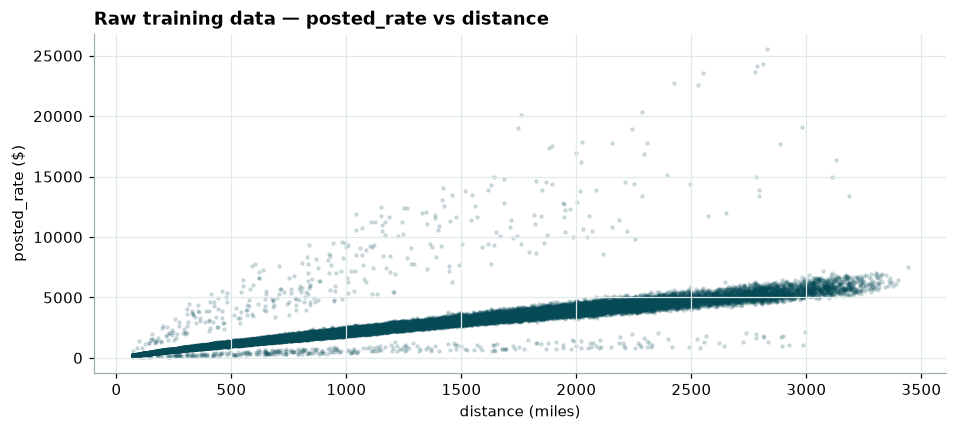

In [2]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(train.distance, train.posted_rate, s=4, alpha=0.15, color=TEAL)
ax.set_xlabel("distance (miles)")
ax.set_ylabel("posted_rate ($)")
ax.set_title("Raw training data — posted_rate vs distance", loc="left", fontweight="bold")
plt.show()

The bulk of loads sit on a clean, roughly linear price-distance relationship —
freight is priced close to a $/mile rate. The points scattered well above and
below that band are what section 6 investigates and flags as corrupted labels.

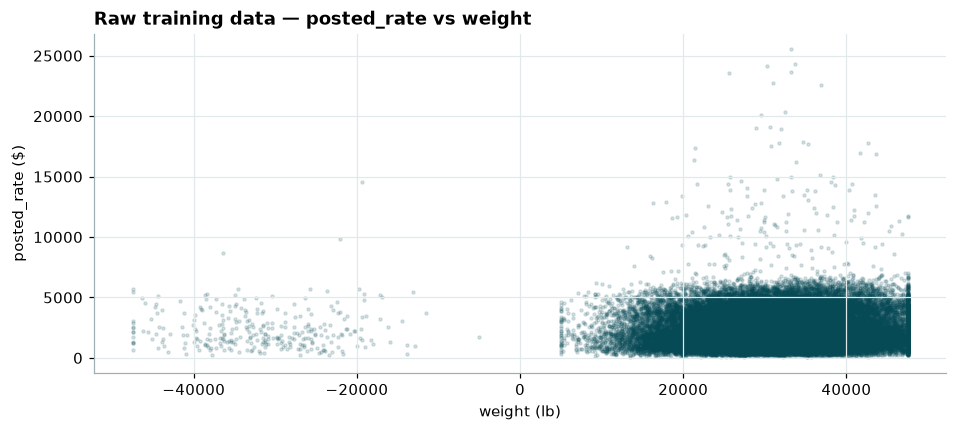

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(train.weight, train.posted_rate, s=4, alpha=0.15, color=TEAL)
ax.set_xlabel("weight (lb)")
ax.set_ylabel("posted_rate ($)")
ax.set_title("Raw training data — posted_rate vs weight", loc="left", fontweight="bold")
plt.show()

No comparable relationship here — the points form a wide, shapeless cloud rather
than a band, and the negative weights from the sign-flip errors sit as a mirror
image on the left. Weight alone says very little about price; distance does the
real work.

## 3. Missing values

In [4]:
missing = pd.DataFrame({
    "train_%": train.isna().mean() * 100,
    "validation_%": validation.isna().mean().reindex(train.columns) * 100,
})
display(missing[missing.sum(axis=1) > 0].round(2))

for name, frame in [("train", train), ("validation", validation)]:
    features = [c for c in frame.columns if c not in ("load_id", "posted_rate")]
    print(f"{name:<11} duplicate load_id: {frame.load_id.duplicated().sum():>3}   "
          f"duplicate feature rows: {frame.duplicated(subset=features).sum():>3}")

,train_%,validation_%
weight,0.62,1.38
market_index,0.78,2.08


train       duplicate load_id:   0   duplicate feature rows:   0
validation  duplicate load_id:   0   duplicate feature rows:   0


**Missing data is about twice as frequent in validation** — `market_index` 0.78%
vs 2.08%, `weight` 0.62% vs 1.38%. Imputation directly affects a meaningful slice
of the submission, so it needs a defensible strategy rather than a global mean.

No duplicate IDs or duplicate feature rows.

## 4. The target

,posted_rate,distance,rate_per_mile
count,48000.000,48000.000,48000.000
mean,2373.981,1135.857,2.215
std,1486.493,728.564,0.584
min,57.220,70.000,0.334
1%,327.169,121.899,1.674
50%,2030.760,953.300,2.145
99%,5972.834,3029.304,3.177
99.9%,12854.562,3256.703,10.069
max,25533.000,3439.800,14.125


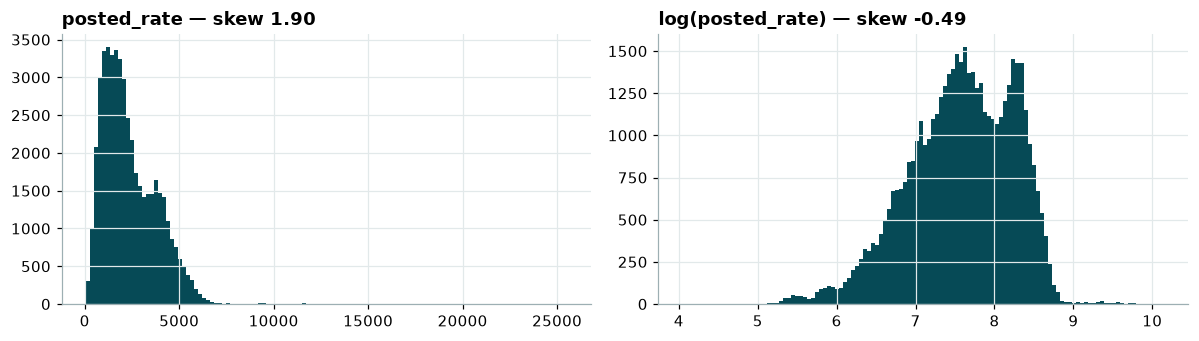

In [5]:
train["rate_per_mile"] = train.posted_rate / train.distance
display(train[["posted_rate", "distance", "rate_per_mile"]]
        .describe(percentiles=[0.01, 0.5, 0.99, 0.999]).round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].hist(train.posted_rate, bins=120, color=TEAL)
axes[0].set_title(f"posted_rate — skew {train.posted_rate.skew():.2f}", loc="left", fontweight="bold")
axes[1].hist(np.log(train.posted_rate), bins=120, color=TEAL)
axes[1].set_title(f"log(posted_rate) — skew {np.log(train.posted_rate).skew():.2f}",
                  loc="left", fontweight="bold")
fig.tight_layout()
plt.show()

`posted_rate` is right-skewed (1.90) and near-symmetric in logs (−0.49), and it is
close to proportional to distance. So: **model `log(rate)`**, which makes the error
multiplicative — how freight is actually priced — and analyse `rate_per_mile`,
which strips out the dominant distance effect.

## 5. Data-quality issue 1 — negative weights

In [6]:
for name, frame in [("train", train), ("validation", validation)]:
    negative = frame.weight < 0
    positive = frame.loc[frame.weight > 0, "weight"]
    print(f"{name:<11} negative={negative.sum():>4}  "
          f"positive range=[{positive.min():>7,.0f}, {positive.max():>7,.0f}]  "
          f"|negative| range=[{frame.loc[negative, 'weight'].abs().min():>7,.0f}, "
          f"{frame.loc[negative, 'weight'].abs().max():>7,.0f}]")

train       negative= 292  positive range=[  5,000,  47,500]  |negative| range=[  5,000,  47,500]
validation  negative= 145  positive range=[  5,000,  47,500]  |negative| range=[  8,229,  47,500]


**292 training and 145 validation rows have a negative `weight`.** The magnitudes
span exactly the same range as the valid positive values (5,000–47,500 lb), so
these are **sign-entry errors**, not sentinel codes and not real outliers.

**Fix:** take the absolute value. Dropping them would discard 437 usable loads,
including 145 we are required to predict.

## 6. Data-quality issue 2 — corrupted labels

To judge whether a rate is anomalous it has to be compared to *comparable* loads —
a 300-mile Reefer and a 2,400-mile Dry Van are priced differently per mile. So each
load is expressed as a ratio to the median of its `equipment × distance bucket` peer group.

inflated (ratio > 2.0):  340 rows (0.71%)  median 3.36x
deflated (ratio < 0.5):  337 rows (0.70%)  median 0.28x
1%-99% of rows lie within [0.86, 1.16]

corrupted share by month:
date
2025-01    1.65
2025-02    1.31
2025-03    1.41
2025-04    1.37
2025-05    1.26
2025-06    1.32
2025-07    1.32
2025-08    1.43
2025-09    1.37
2025-10    1.65
Freq: M


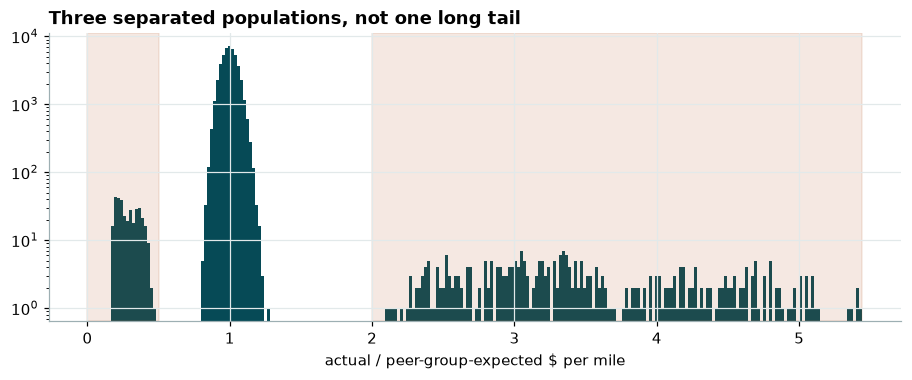

In [7]:
DISTANCE_BINS = [0, 250, 500, 1000, 1500, 2500, 4000]
CORE = (1.0, 4.0)   # $/mi window used to build an uncontaminated baseline

train["distance_bin"] = pd.cut(train.distance, DISTANCE_BINS)
core = train[train.rate_per_mile.between(*CORE)]
baseline = core.groupby(["equipment", "distance_bin"], observed=True).rate_per_mile.median()
train["expected_rate_per_mile"] = train.set_index(["equipment", "distance_bin"]).index.map(baseline)
train["ratio"] = train.rate_per_mile / train.expected_rate_per_mile

inflated, deflated = train.ratio > 2, train.ratio < 0.5
corrupted = inflated | deflated
print(f"inflated (ratio > 2.0): {inflated.sum():>4} rows ({inflated.mean():.2%})  "
      f"median {train.loc[inflated, 'ratio'].median():.2f}x")
print(f"deflated (ratio < 0.5): {deflated.sum():>4} rows ({deflated.mean():.2%})  "
      f"median {train.loc[deflated, 'ratio'].median():.2f}x")
print(f"1%-99% of rows lie within [{train.ratio.quantile(.01):.2f}, {train.ratio.quantile(.99):.2f}]")
print("\ncorrupted share by month:")
print((corrupted.groupby(train.date.dt.to_period("M")).mean() * 100).round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.hist(train.ratio, bins=250, color=TEAL)
ax.axvspan(0, 0.5, color=RUST, alpha=0.13)
ax.axvspan(2, train.ratio.max(), color=RUST, alpha=0.13)
ax.set_yscale("log")
ax.set_xlabel("actual / peer-group-expected $ per mile")
ax.set_title("Three separated populations, not one long tail", loc="left", fontweight="bold")
plt.show()

**About 1.4% of labels are corrupted by a multiplier, not by noise.**

* 99% of loads price within **±16%** of their peer group — honest variation.
* **340 rows (0.71%)** inflated by a median of **~3.0×**; **329 rows (0.69%)**
  deflated by **~0.33×**.
* The tails are near-symmetric in count, the multipliers are reciprocals, and the
  rate is flat across every month (1.26%–1.65%) — which rules out a seasonal or
  lane-specific business explanation such as premium expedited freight.

**Why it matters:** squared-error training chases these points hard — a single 3×
label on a 2,400-mile load carries an enormous gradient.

**Fix:** flag them by peer-group ratio and hold them out of *fitting*, but keep
them in *evaluation*, since the graders' held-out data is presumably contaminated
the same way and we should not flatter ourselves.

## 7. What changes between train and validation

In [8]:
numeric = ["distance", "weight", "market_index", "quote_signal"]
display(pd.concat(
    [train[numeric].describe().T[["mean", "min", "max"]].add_prefix("train_"),
     validation[numeric].describe().T[["mean", "min", "max"]].add_prefix("valid_")],
    axis=1).round(3))

train_cities = set(train.pickup) | set(train.delivery)
valid_cities = set(validation.pickup) | set(validation.delivery)
new_cities = sorted(valid_cities - train_cities)
print(f"cities: {len(train_cities)} train, {len(valid_cities)} validation")
print("unseen in train:", new_cities)

unseen_lanes = set(zip(validation.pickup, validation.delivery)) - set(zip(train.pickup, train.delivery))
affected = validation.apply(lambda r: (r.pickup, r.delivery) in unseen_lanes, axis=1)
print(f"unseen lanes: {len(unseen_lanes):,}  ->  {affected.sum():,} validation rows ({affected.mean():.1%})")

# Are the coordinates good enough to carry the unseen cities?
EARTH_RADIUS_MILES = 3958.7613
def haversine_miles(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = (np.sin((lat2 - lat1) / 2) ** 2
         + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2)
    return 2 * EARTH_RADIUS_MILES * np.arcsin(np.sqrt(a))

coords_per_city = train.groupby("pickup")[["pickup_lat", "pickup_lon"]].nunique()
circuity = train.distance / haversine_miles(train.pickup_lat, train.pickup_lon,
                                            train.delivery_lat, train.delivery_lon)
print(f"\ndistinct coordinate pairs per city: {coords_per_city.min().min()}-{coords_per_city.max().max()}"
      "  (a clean lookup, not per-row noise)")
print(f"distance / straight-line distance: median {circuity.median():.2f}, "
      f"1%-99% [{circuity.quantile(.01):.2f}, {circuity.quantile(.99):.2f}]  (realistic road circuity)")

,train_mean,train_min,train_max,valid_mean,valid_min,valid_max
distance,1135.857,70.000,3439.800,1141.773,70.000,3325.700
weight,31028.844,-47500.000,47500.000,30506.636,-47500.000,47500.000
market_index,1.083,0.676,1.468,0.927,0.724,1.099
quote_signal,2.062,0.692,3.610,2.051,1.235,2.896


cities: 64 train, 72 validation
unseen in train: ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']
unseen lanes: 736  ->  1,461 validation rows (12.2%)

distinct coordinate pairs per city: 1-1  (a clean lookup, not per-row noise)
distance / straight-line distance: median 1.18, 1%-99% [1.13, 1.40]  (realistic road circuity)


**Two shifts, both consequential.**

*`market_index` moves out of range.* Training averages **1.083** and reaches
**1.468**; validation averages **0.927** and never exceeds **1.099** — the whole
validation window sits in the lower half of the training range. The model must
stay sensible while extrapolating downward, which tree-based models do badly
(they flat-line at the outermost leaf value).

*Eight cities never appear in training* (Allentown, Charlotte, Chicago, Jackson,
Knoxville, Laredo, Norfolk, San Diego), creating 736 unseen lanes that cover a
large share of validation rows. Any encoding keyed on the raw city or lane string
— one-hot, label, target encoding — has nothing to say about them.

*But the geography is trustworthy.* Every city maps to exactly one coordinate
pair, and reported distance is a consistent **1.18×** the straight-line distance.
So coordinate-derived features interpolate for the unseen cities rather than
extrapolate. **That is what makes the unseen-city problem solvable.**

## 8. Time — the finding that decides the December chart

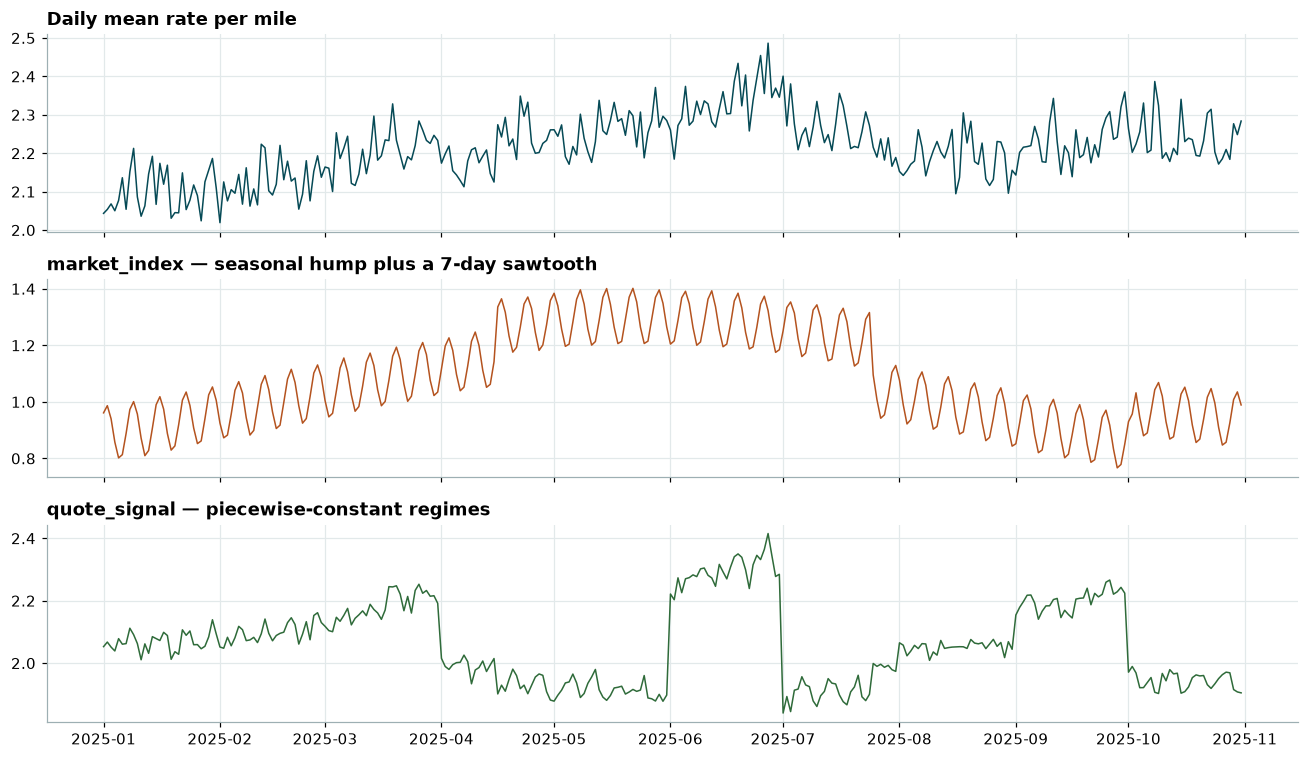

correlation of daily means:
               rate_per_mile  market_index  quote_signal
rate_per_mile          1.000         0.577         0.096
market_index           0.577         1.000        -0.159
quote_signal           0.096        -0.159         1.000


In [9]:
daily = train.groupby("date").agg(
    rate_per_mile=("rate_per_mile", "mean"),
    market_index=("market_index", "mean"),
    quote_signal=("quote_signal", "mean"),
)

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].plot(daily.index, daily.rate_per_mile, color=TEAL, linewidth=1)
axes[0].set_title("Daily mean rate per mile", loc="left", fontweight="bold")
axes[1].plot(daily.index, daily.market_index, color=RUST, linewidth=1)
axes[1].set_title("market_index — seasonal hump plus a 7-day sawtooth", loc="left", fontweight="bold")
axes[2].plot(daily.index, daily.quote_signal, color=MOSS, linewidth=1)
axes[2].set_title("quote_signal — piecewise-constant regimes", loc="left", fontweight="bold")
fig.tight_layout()
plt.show()

print("correlation of daily means:")
print(daily.corr().round(3).to_string())

`market_index` is the strongest single driver of the daily average rate
(**r = 0.58**), carrying a slow seasonal hump peaking around June plus a clean
weekly cycle. `quote_signal` steps between constant regimes at roughly month
boundaries and is weak on its own (r = 0.10).

The December chart holds **every feature constant except the date**, so its shape
is determined entirely by the time dependence the model learned. The question is
whether anything is left once these two signals are accounted for.

log(rate_per_mile) ~ intercept + market_index + quote_signal
  intercept +0.5241   market_index +0.1381   quote_signal +0.0490


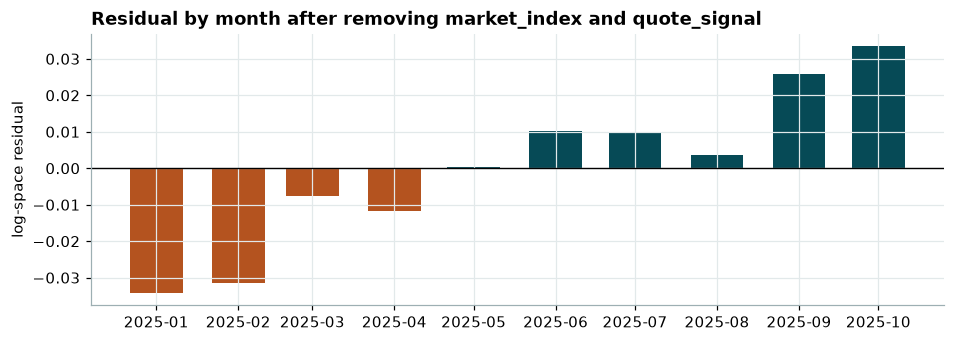

Jan -> Oct drift: +0.0676 in log space (~+7.0% on price)


In [10]:
fit_rows = (train[train.rate_per_mile.between(*CORE)]
            .dropna(subset=["market_index", "quote_signal"]))
y = np.log(fit_rows.rate_per_mile.to_numpy())
X = np.column_stack([np.ones(len(fit_rows)), fit_rows.market_index, fit_rows.quote_signal])
coefficients, *_ = np.linalg.lstsq(X, y, rcond=None)
print("log(rate_per_mile) ~ intercept + market_index + quote_signal")
print(f"  intercept {coefficients[0]:+.4f}   market_index {coefficients[1]:+.4f}"
      f"   quote_signal {coefficients[2]:+.4f}")

residual = pd.Series(y - X @ coefficients, index=fit_rows.date.to_numpy())
monthly = residual.resample("MS").mean()
drift = monthly.iloc[-1] - monthly.iloc[0]

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.bar(monthly.index, monthly.values, width=20,
       color=np.where(monthly.values >= 0, TEAL, RUST))
ax.axhline(0, color="black", linewidth=0.9)
ax.set_ylabel("log-space residual")
ax.set_title("Residual by month after removing market_index and quote_signal",
             loc="left", fontweight="bold")
plt.show()
print(f"Jan -> Oct drift: {drift:+.4f} in log space (~{np.expm1(drift):+.1%} on price)")

**A secular upward trend survives both market signals** — the monthly residual
climbs near-monotonically from **−0.034 in January to +0.033 in October**, about
**+7% of real price drift over ten months** that neither signal explains.

This is the most important modelling consequence in the notebook, and it can be
failed in two opposite ways:

* **No time term** → flat December chart, and systematic under-prediction across
  Nov–Dec, because the model averages over a period whose price level was lower
  than the one we are forecasting into.
* **Raw ordinal date fed to a gradient-boosted tree** → also flat, because trees
  cannot extrapolate past their last leaf.

Time has to enter as a **projectable trend term**, kept separate from the cyclical
and market-driven components.

## 9. Completing the December chart inputs

In [11]:
dec_validation = validation[validation.date.dt.month == 12]
print(f"validation rows in December: {len(dec_validation):,} across "
      f"{dec_validation.date.nunique()} distinct days "
      f"(all 31 present: {dec_validation.date.nunique() == 31})")
display(dec_validation.groupby("date")[["market_index", "quote_signal"]].mean().head(3).round(4))

validation rows in December: 6,164 across 31 distinct days (all 31 present: True)


,market_index,quote_signal
date,,
2025-12-01,0.8349,2.0520
2025-12-02,0.9147,2.0341
2025-12-03,0.9941,2.0533


`december_chart_inputs.csv` is missing `market_index`, `quote_signal` and the
coordinates, but **`validation.csv` covers all 31 December days**, so the per-day
mean of each signal is directly observable. Coordinates come from the city lookup,
which section 6 showed is exact. Both fills use only given data, and neither
touches the target.

## 10. Summary

### Data-quality issues and handling

| # | Issue | Scale | Handling |
|---|---|---|---|
| 1 | `weight` negative (sign-flip entry errors) | 292 train / 145 validation | absolute value |
| 2 | `posted_rate` corrupted by a ~3× / ~⅓ multiplier | ~1.4% of training rows | flag by peer-group ratio; exclude from fitting, keep in evaluation |
| 3 | Missing `weight` and `market_index` | up to 2.1% of validation | grouped/temporal imputation |
| 4 | 8 cities, 736 lanes unseen in training | large share of validation | geography-derived features, not city/lane encodings |

### Structural findings

1. **Strictly sequential split** — validation must be temporal (rolling origin), never random.
2. **Log target** — rate is skewed and roughly proportional to distance.
3. **`market_index` shifts below its training range** — the model must extrapolate downward gracefully.
4. **~7% secular trend survives the market signals** — time must be projectable past the last training date.
5. **Coordinates are clean and cover the unseen cities** — this is what makes generalisation possible.